<a href="https://colab.research.google.com/github/scxbbard/Data-science-classes/blob/main/Analysisonobesity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
##import libraries
import pandas as pd

df = pd.read_csv("/content/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip")

In [15]:
##importing more libraries to be able to analyse the dataset
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


##**Key**
1. FAVC - Do you eat high caloric food frequently?
2. FCVC - Do you usually eat vegetables in your meals?
3. NCP - How many main meals do you have daily?
4. CAEC - Do you eat any food between meals?
5. SMOKE - Do you smoke?

In [2]:
##load the first 10 rows of the data
df.head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [3]:
#loading the last 10 rows
df.tail(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
2101,Female,25.722004,1.628470,107.218949,yes,yes,3.0,3.0,Sometimes,no,2.487070,no,0.067329,0.455823,Sometimes,Public_Transportation,Obesity_Type_III
2102,Female,25.765628,1.627839,108.107360,yes,yes,3.0,3.0,Sometimes,no,2.320068,no,0.045246,0.413106,Sometimes,Public_Transportation,Obesity_Type_III
2103,Female,21.016849,1.724268,133.033523,yes,yes,3.0,3.0,Sometimes,no,1.650612,no,1.537639,0.912457,Sometimes,Public_Transportation,Obesity_Type_III
2104,Female,21.682367,1.732383,133.043941,yes,yes,3.0,3.0,Sometimes,no,1.610768,no,1.510398,0.931455,Sometimes,Public_Transportation,Obesity_Type_III
2105,Female,21.285965,1.726920,131.335786,yes,yes,3.0,3.0,Sometimes,no,1.796267,no,1.728332,0.897924,Sometimes,Public_Transportation,Obesity_Type_III
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III
2110,Female,23.664709,1.738836,133.472641,yes,yes,3.0,3.0,Sometimes,no,2.863513,no,1.026452,0.714137,Sometimes,Public_Transportation,Obesity_Type_III


In [4]:
###checking how many rows and columns the data has
df.shape

(2111, 17)

In [5]:
##checking the datatyps of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [13]:
###checking data types of each column
df.dtypes

,0
Gender,object
Age,float64
Height,float64
Weight,float64
family_history_with_overweight,object
FAVC,object
FCVC,float64
NCP,float64
CAEC,object
SMOKE,object


In [6]:
##checking for missing values
df.isna().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [7]:
##checking for number duplicates
df.duplicated().sum()

np.int64(24)

In [8]:
##checking for duplicates
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
2106,False
2107,False
2108,False
2109,False


In [9]:
###droping duplicates
df.drop_duplicates(inplace=True)


In [10]:
##counterchecking for duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
##displaying the dataset again
df.head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [12]:
##checking statistics
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730,2.421466,2.701179,2.004749,1.012812,0.663035
std,6.368801,0.093186,26.190847,0.534737,0.764614,0.608284,0.853475,0.608153
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.915937,1.630178,66.000000,2.000000,2.697467,1.590922,0.124505,0.000000
50%,22.847618,1.701584,83.101100,2.396265,3.000000,2.000000,1.000000,0.630866
75%,26.000000,1.769491,108.015907,3.000000,3.000000,2.466193,1.678102,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


##**Key**
1. FAVC - Do you eat high caloric food frequently?
2. FCVC - Do you usually eat vegetables in your meals?
3. NCP - How many main meals do you have daily?
4. CAEC - Do you eat any food between meals?
5. SMOKE - Do you smoke?
6. CH2O	- How much water do you drink daily?
7. SCC	- Do you monitor the calories you eat daily?
8. FAF	- How often do you have physical activity?
9. TUE	- How much time do you use technological devices such as cell phone, videogames, television, computer and others?
10. CALC	- How often do you drink alcohol?
11. MTRANS -	Which transportation do you usually use?
12. NObeyesdad -	Obesity level


##**Checking the distribution of the obesity level in each category**

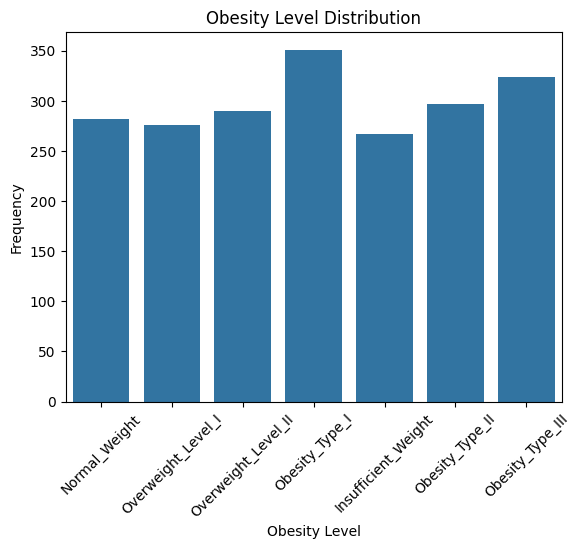

In [17]:
###plotting thr graph for the distribution
sns.countplot(x='NObeyesdad', data=df)
plt.title("Obesity Level Distribution")
plt.xlabel("Obesity Level")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

- The graph shows that most of the population is obesed, normal weight is preceded by overweight whereas a small porion of the population fall in the insufficient weight category.

##**Age distribution**


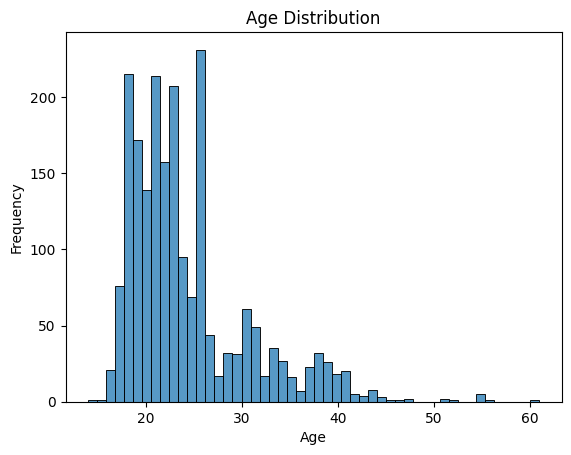

In [23]:
###generating the age distribution graph
sns.histplot(df['Age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**The population comprises mostly of young people**

##**Weight distribution**

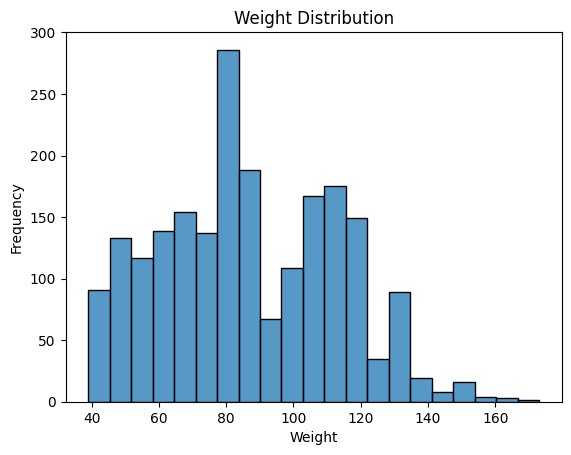

In [26]:
###generating the weight distribution graph
sns.histplot(df['Weight'])
plt.title("Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.show()

**The weight of majority of the population is 80kg and above**

##**Height distribution**

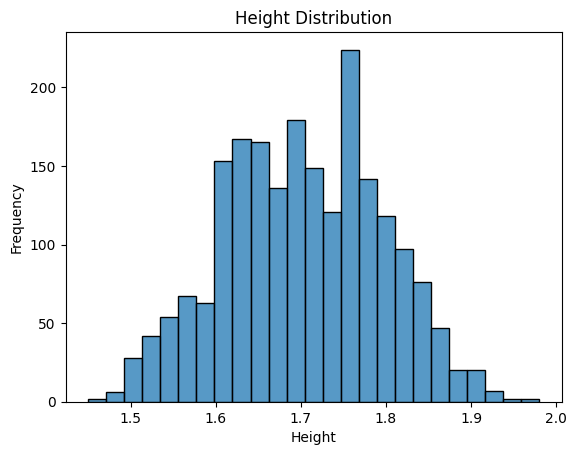

In [27]:
##generating the height distribution graph
sns.histplot(df['Height'])
plt.title("Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

**The height of most people ranges from about ***1.6m - 1.8m*****

#**Lifestyle habits**

##**Snacking**

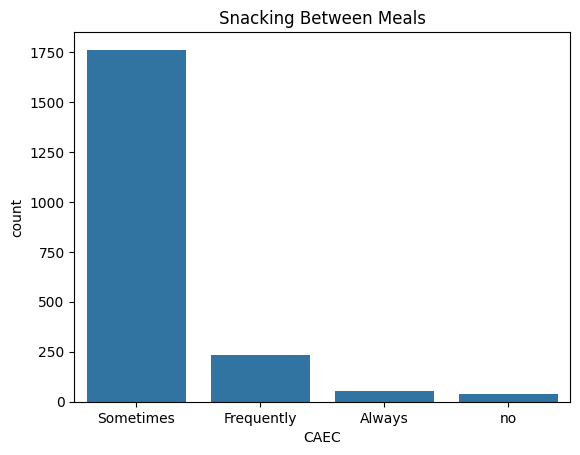

In [29]:
##A graph that shows if ppl snack in btwn meals
sns.countplot(x="CAEC", data=df)
plt.title("Snacking Between Meals")
plt.show()

##**Alcohol intake**


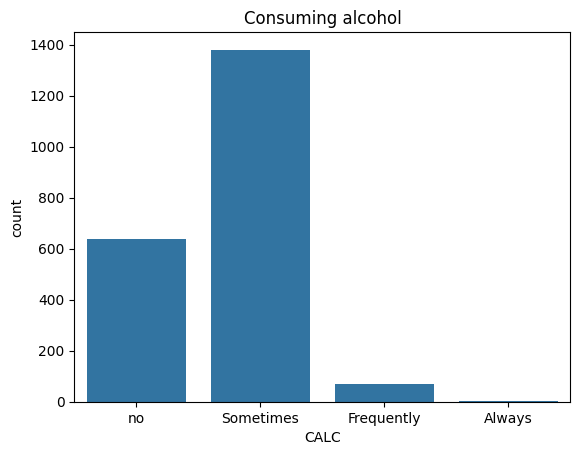

In [31]:
##to show alcohol consumption
sns.countplot(x="CALC", data=df)
plt.title("Consuming alcohol")
plt.show()

**Most of the population consumes alcohol which may be the reason for high numbers of obesity**

##**Mode of transport**

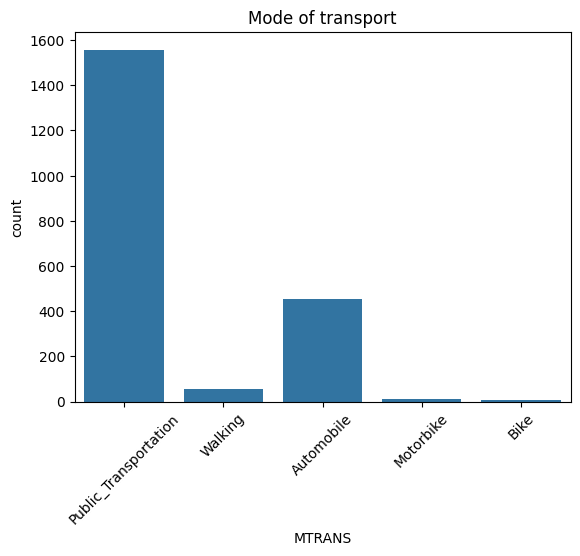

In [33]:
##To show mode of transport in the population
sns.countplot(x="MTRANS", data=df)
plt.title("Mode of transport")
plt.xticks(rotation=45)
plt.show()

**Few people either walk or cycle which is why a minority of the population occupy the normal weight category. This also shows that most of the popuation is physically inactive, which is why most are either obese or overweight.**

##**Monitoring calories**

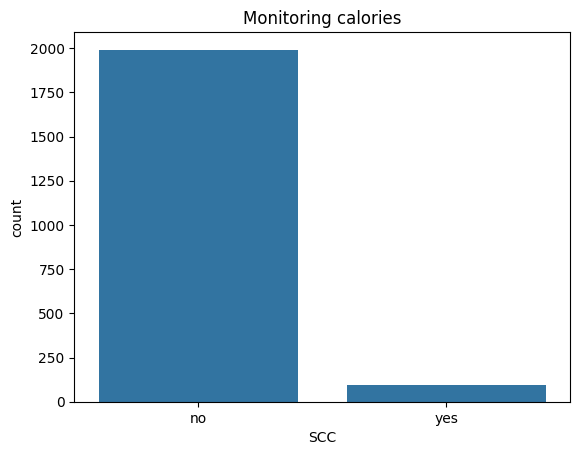

In [35]:
##To show monitoring calories in the population
sns.countplot(x="SCC", data=df)
plt.title("Monitoring calories")
plt.show()


**Lack of monitoring calories may most likely lead to obesity or being overweight.**

#**Average age per obesity level**

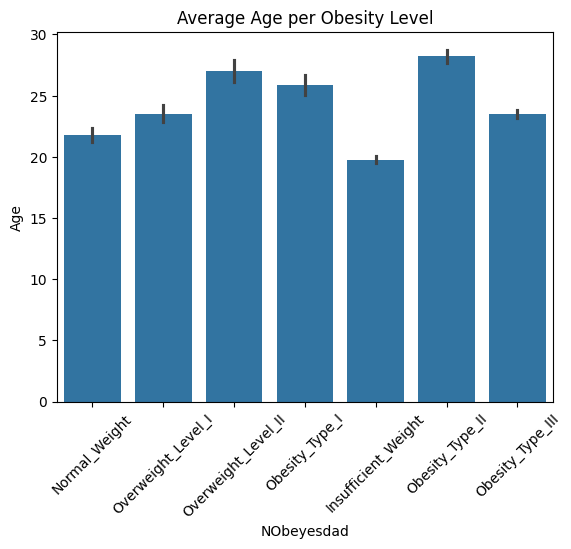

In [38]:
#To show average age per obesity level
sns.barplot(x="NObeyesdad", y="Age", data=df)
plt.title("Average Age per Obesity Level")
plt.xticks(rotation=45)
plt.show()

**Being overweight and obese is mostly seen among young adults**

##**Recommendations**
1. Population should be phsically active.
2. Cut down on alcohol consumption.
3. Monitor calories.
4. Minimize snacking in between meals.
